In [1]:
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    pass


Saving Advertising.csv to Advertising.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Advertising.csv')
df.head()


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


##Exploring the data

In [3]:
print("Shape:", df.shape)
print()
print(df.info())
print()
print("Missing values per column:")
print(df.isnull().sum())


Shape: (200, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Missing values per column:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [4]:
df.describe()


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


##Cleaning the data
The first column is just a row index with no name — it carries no information, so we drop it.

In [5]:
df = df.drop(columns=[df.columns[0]])
df.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


##Visualize relationships
Before modeling, check how each advertising channel relates to sales, and how the channels relate to each other.

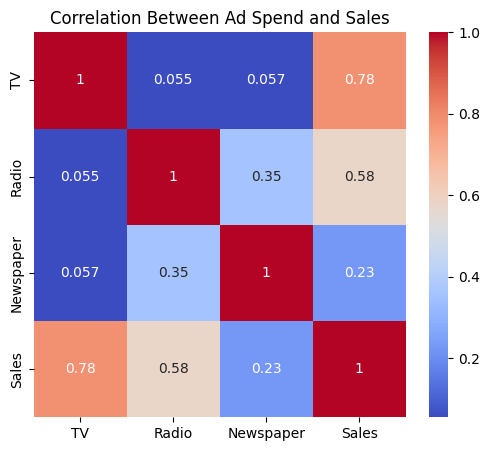

In [6]:
corr = df.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Ad Spend and Sales')
plt.show()


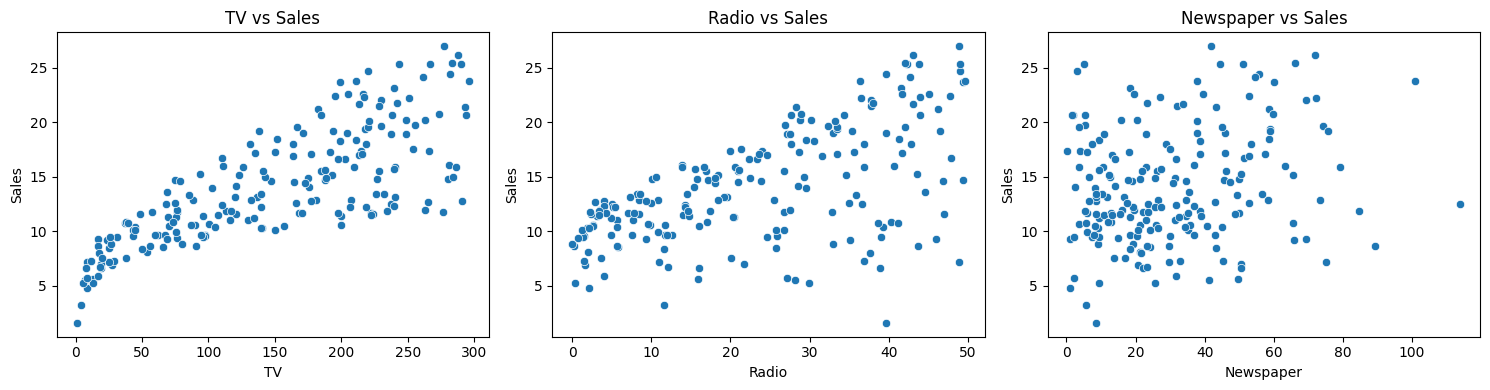

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['TV', 'Radio', 'Newspaper']):
    sns.scatterplot(x=col, y='Sales', data=df, ax=ax)
    ax.set_title(f'{col} vs Sales')
plt.tight_layout()
plt.show()


**What to look for:** TV usually shows the strongest, clearest upward relationship with Sales. Radio has a moderate relationship. Newspaper tends to be the weakest — the points look scattered with little clear trend.

##Preparing data for modeling

In [8]:
from sklearn.model_selection import train_test_split

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Training samples: 160
Test samples: 40


##Train a regression model
Sales is a continuous number, not a category, so we use **Linear Regression** instead of a classifier.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("R2 Score:", r2_score(y_test, preds))
print("Mean Squared Error:", mean_squared_error(y_test, preds))


R2 Score: 0.899438024100912
Mean Squared Error: 3.1740973539761033


##Interpret the model
The model's coefficients tell us how much Sales changes for every one-unit increase in ad spend on each channel, holding the others constant.

In [10]:
coefficients = pd.DataFrame({
    'Channel': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

coefficients


,Channel,Coefficient
1,Radio,0.189195
0,TV,0.044730
2,Newspaper,0.002761


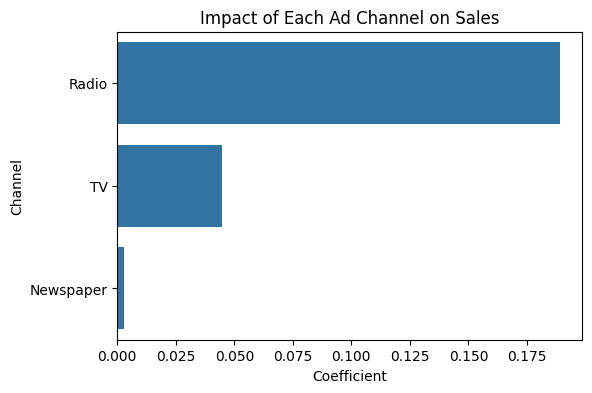

In [11]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Coefficient', y='Channel', data=coefficients)
plt.title('Impact of Each Ad Channel on Sales')
plt.show()


##Check predictions visually

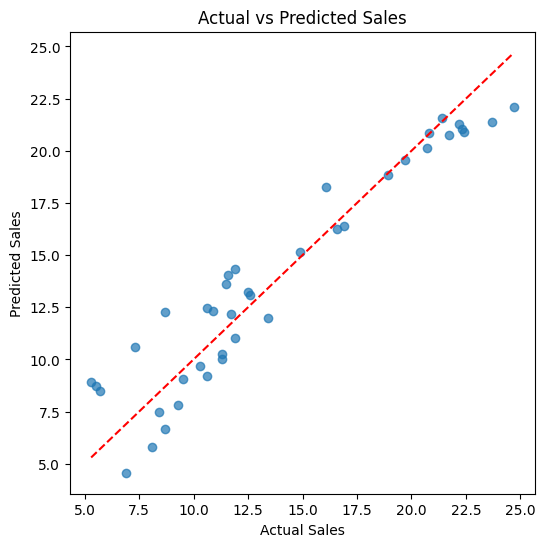

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()


Conclusions

- TV advertising has the strongest impact on sales, followed by Radio.
- Newspaper advertising shows the weakest relationship with sales — spend here has the least payoff.
- The linear regression model explains a high proportion of the variance in sales (check the R² score above — typically above 0.85 for this dataset).
- **Business takeaway:** if a company needs to reallocate a limited ad budget, shifting more spend toward TV and Radio (and less toward Newspaper) is likely to have the biggest impact on sales.
